In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
#Data loading
housing=pd.read_csv("Data/housing.csv")
df=pd.DataFrame(housing)
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [3]:
# Data Cleaning
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
#Encoding categorical data
df = pd.get_dummies(df, columns=["ocean_proximity"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  bool   
 10  ocean_proximity_INLAND      20640 non-null  bool   
 11  ocean_proximity_ISLAND      20640 non-null  bool   
 12  ocean_proximity_NEAR BAY    20640 non-null  bool   
 13  ocean_proximity_NEAR OCEAN  20640 non-null

In [4]:
#Feature Enginnering
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] /df["households"]
housing=df

In [5]:
#Train Test Split
from sklearn.model_selection import train_test_split
x = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(16512, 16) (4128, 16)


In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

housing["income_cat"] = pd.cut(housing["median_income"],
                                bins=[0, 1.5, 3.0, 4.5, 6.0, float("inf")],
                                labels=[1, 2, 3, 4, 5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index].drop("income_cat", axis=1)
    strat_test_set = housing.loc[test_index].drop("income_cat", axis=1)

housing.drop("income_cat", axis=1, inplace=True)
print(strat_train_set.shape, strat_test_set.shape)


(16512, 17) (4128, 17)


In [7]:
x_train=strat_train_set.drop("median_house_value",axis=1)
y_train=strat_train_set["median_house_value"].copy()
x_test=strat_test_set.drop("median_house_value",axis=1)
y_test=strat_test_set["median_house_value"].copy()

In [8]:
#ML pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
my_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])
x_train = my_pipeline.fit_transform(x_train)
x_test=my_pipeline.transform(x_test)

Root Mean Squared Error:66,914.99
mean_squared_error:4,477,616,505.62
R2 Score:0.66


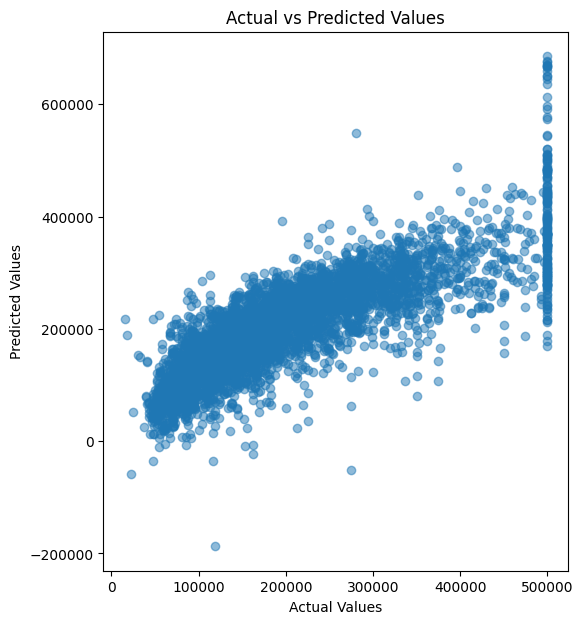

In [9]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
model=LinearRegression()
model.fit(x_train,y_train)
pred1=model.predict(x_test)
mse=mean_squared_error(y_test,pred1)
rmse=np.sqrt(mse)
print(f"Root Mean Squared Error:{rmse:,.2f}")
print(f"mean_squared_error:{mse:,.2f}")
print(f"R2 Score:{r2_score(y_test,pred1):.2f}")
# Actual vs Predicted 
plt.figure(figsize=(6,7))
plt.scatter(y_test, pred1, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

Root Mean Squared Error:48,585.16
mean_squared_error:2,360,517,577.52
R2 Score:0.66


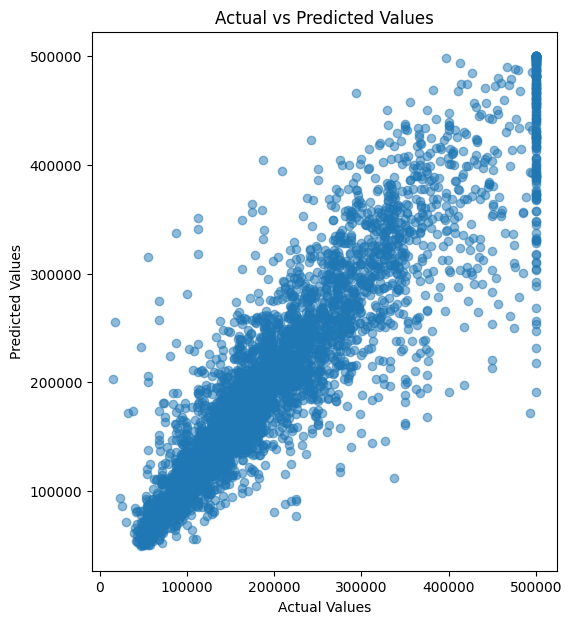

In [10]:
#Random Forest Reggresor
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
model.fit(x_train,y_train)
pred=model.predict(x_test)
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
print(f"Root Mean Squared Error:{rmse:,.2f}")
print(f"mean_squared_error:{mse:,.2f}")
print(f"R2 Score:{r2_score(y_test,pred1):.2f}")
# Actual vs Predicted 
plt.figure(figsize=(6,7))
plt.scatter(y_test, pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()


In [11]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x_train, y_train, 
                         scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-scores)
print(f"Mean RMSE: {rmse_scores.mean():,.2f}")
print(f"Std: {rmse_scores.std():,.2f}")


Mean RMSE: 50,709.36
Std: 753.05


Root Mean Squared Error:48,585.16
mean_squared_error:2,360,517,577.52
R2 Score:0.66


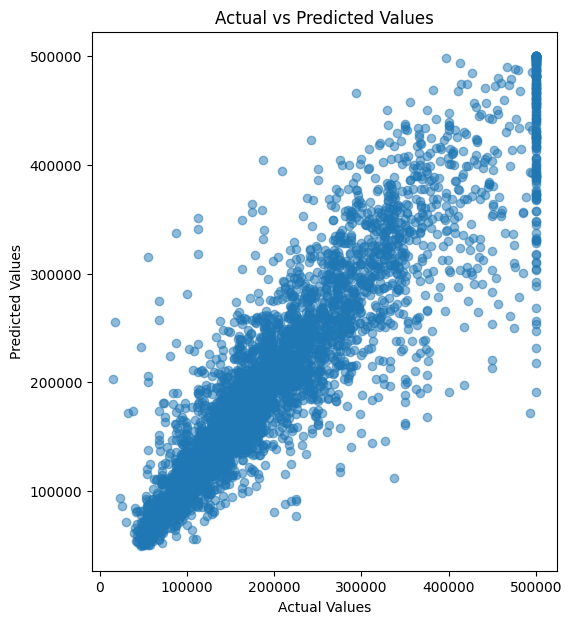

In [12]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
model3=DecisionTreeRegressor()
model3.fit(x_train,y_train)
pred3=model.predict(x_test)
mse=mean_squared_error(y_test,pred3)
rsme=np.sqrt(mse)
print(f"Root Mean Squared Error:{rsme:,.2f}")  
print(f"mean_squared_error:{mse:,.2f}")
print(f"R2 Score:{r2_score(y_test,pred1):.2f}")
# Actual vs Predicted 
plt.figure(figsize=(6,7))
plt.scatter(y_test, pred3, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [13]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
xgb_reg=xgb.XGBRegressor(random_state=42,tree_method="hist")
param_dist={
    "n_estimators":[100,200,300],
    "learning_rate":[0.01,0.1,0.2],
    "max_depth":[3,5,7],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0]
}
random_search=RandomizedSearchCV(estimator=xgb_reg,param_distributions=param_dist,n_iter=20,cv=5,scoring="neg_root_mean_squared_error",verbose=2,random_state=42,n_jobs=-1)
random_search.fit(x_train,y_train)

best_xgb=random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [14]:
#Test on the test set
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np 
predictions = best_xgb.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f"XGBoost RMSE: {rmse:,.2f}")
print(f"XGBoost R2 Score: {r2:.2f}")


XGBoost RMSE: 44,626.98
XGBoost R2 Score: 0.85


In [15]:
import joblib
joblib.dump(best_xgb, "backend/models/xgb_model.pkl")

['backend/models/xgb_model.pkl']